# Analyizing old MIEZE data.
# Run 13018 (sftp://uff@analysis.sns.gov/gpfs/neutronsfs/instruments-hfir/NOWG/IPTS-31333/images/tpx3/Run_13039/Run_13039_9FLRp_000000.tpx3)
- Using LiI scintillator
- Nhit min 20
- abs range 1 us

## 1. Setup and Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")
print(f"Numpy version: {np.__version__}")

# Setup plotting
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

Matplotlib is building the font cache; this may take a moment.


: 

## 2. Data File Setup

In [2]:
# Ni powder file path
data_path = "/gpfs/neutronsfs/instruments-hfir/NOWG/IPTS-31333/images/tpx3/Run_41676/"
ni_file = "Run_41676_fBCFYv_000000.tpx3"
ni_full_path = os.path.join(data_path, ni_file)

# Verify file exists
if os.path.exists(ni_full_path):
    size_mb = os.path.getsize(ni_full_path) / (1024 * 1024)
    print(f"✅ Ni powder file found: {ni_file}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ File not found: {ni_full_path}")
    print("Please ensure the data file is in the correct location")

✅ Ni powder file found: Run_41676_fBCFYv_000000.tpx3
   Size: 239.0 MB


## 3. Raw Data → Hits Processing

In [3]:
print("=== Processing TPX3 file to hits ===")

start_time = time.time()

# Process the file using TDCSophiread (high-level convenience function)
# NEW: Returns TDCHitView for zero-copy numpy access
hit_view = tdc.process_tpx3(ni_full_path, parallel=True)

# Convert to numpy array (zero-copy)
hits = np.array(hit_view, copy=False)

processing_time = time.time() - start_time

print(f"✅ Processing completed in {processing_time:.2f} seconds")
print(f"✅ Total hits extracted: {len(hits):,}")
print(f"✅ Processing rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")

# Display hit data structure
print("\nHit data structure:")
for field in hits.dtype.names:
    array = hits[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    print(f"    range: {array.min()} - {array.max()}")

=== Processing TPX3 file to hits ===
✅ Processing completed in 0.80 seconds
✅ Total hits extracted: 31,262,905
✅ Processing rate: 39.2 M hits/second

Hit data structure:
  tof: uint32, shape (31262905,)
    range: 0 - 666161
  x: uint16, shape (31262905,)
    range: 258 - 513
  y: uint16, shape (31262905,)
    range: 0 - 255
  timestamp: uint32, shape (31262905,)
    range: 60814 - 1074216967
  tot: uint16, shape (31262905,)
    range: 1 - 297
  chip_id: uint8, shape (31262905,)
    range: 0 - 0
  cluster_id: int32, shape (31262905,)
    range: -1 - -1


## 4. Clustering Configuration

In [4]:
print("=== Setting up clustering configuration ===")

# Create neutron processing configuration with VENUS defaults
config = tdc.NeutronProcessingConfig.venus_defaults()
config.extraction.min_tot_threshold = 0
config.temporal.enable_deduplication = False
config.clustering.abs.min_cluster_size=25
config.clustering.abs.neutron_correlation_window=1400  # ns
config.extraction.super_resolution_factor=2

print("VENUS default neutron processing configuration:")
print(f"  Clustering algorithm: {config.clustering.algorithm}")
print(f"  Extraction algorithm: {config.extraction.algorithm}")

print("\nABS clustering parameters:")
print(f"  Spatial radius: {config.clustering.abs.radius} pixels")
print(f"  Min cluster size: {config.clustering.abs.min_cluster_size} hits")
print(f"  Time range: {config.clustering.abs.neutron_correlation_window} ns")

print("\nCentroid extraction parameters:")
print(f"  Super resolution: {config.extraction.super_resolution_factor}x")
print(f"  TOT weighted: {config.extraction.weighted_by_tot}")
print(f"  Min TOT threshold: {config.extraction.min_tot_threshold}")

print("\nTemporal processing parameters:")
print(f"  Number of workers: {config.temporal.num_workers}")
print(f"  Min batch size: {config.temporal.min_batch_size}")
print(f"  Max batch size: {config.temporal.max_batch_size}")

=== Setting up clustering configuration ===
VENUS default neutron processing configuration:
  Clustering algorithm: abs
  Extraction algorithm: simple_centroid

ABS clustering parameters:
  Spatial radius: 5.0 pixels
  Min cluster size: 25 hits
  Time range: 1400.0 ns

Centroid extraction parameters:
  Super resolution: 2.0x
  TOT weighted: True
  Min TOT threshold: 0

Temporal processing parameters:
  Number of workers: 0
  Min batch size: 1000
  Max batch size: 100000


## 5. Hits → Neutrons Clustering

In [5]:
print("=== Clustering hits to neutrons ===")
print(f"Input: {len(hits):,} hits")

start_time = time.time()

# Process hits to neutrons using the new zero-copy interface
# This function accepts both numpy arrays and TDCHitView
neutron_view = tdc.process_hits_to_neutrons(hits, config)

clustering_time = time.time() - start_time

print(f"✅ Clustering completed in {clustering_time:.2f} seconds")

=== Clustering hits to neutrons ===
Input: 31,262,905 hits
✅ Clustering completed in 0.37 seconds


In [6]:
print("Exposing neutron data as numpy array for zero-copy access")
start_time = time.time()
# Convert to numpy array (zero-copy)
neutrons = np.array(neutron_view, copy=False)
processing_time = time.time() - start_time
print(f"✅ Neutron data exposed in {processing_time:.2f} seconds")
print(f"✅ Output neutrons: {len(neutrons):,}")
print(f"✅ Clustering rate: {len(hits) / clustering_time:.0f} hits/second")


Exposing neutron data as numpy array for zero-copy access
✅ Neutron data exposed in 0.00 seconds
✅ Output neutrons: 217,903
✅ Clustering rate: 84417936 hits/second


In [7]:
# Calculate clustering efficiency
efficiency = len(neutrons) / len(hits)
print(f"✅ Neutron extraction efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")

# Display neutron data structure
print("\nNeutron data structure:")
for field in neutrons.dtype.names:
    array = neutrons[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    if field in ["x", "y"]:
        print(f"    range: {array.min():.2f} - {array.max():.2f} (sub-pixel)")
    else:
        print(f"    range: {array.min()} - {array.max()}")

✅ Neutron extraction efficiency: 0.006970 (0.6970%)

Neutron data structure:
  x: float64, shape (217903,)
    range: 527.09 - 1020.48 (sub-pixel)
  y: float64, shape (217903,)
    range: 10.17 - 504.50 (sub-pixel)
  tof: uint32, shape (217903,)
    range: 0 - 666090
  tot: uint16, shape (217903,)
    range: 128 - 7050
  n_hits: uint16, shape (217903,)
    range: 25 - 344
  chip_id: uint8, shape (217903,)
    range: 0 - 0
  reserved: uint8, shape (217903,)
    range: 0 - 0


## 6. Clustering Results Analysis

In [8]:
print("=== Clustering Results Analysis ===")

# Get neutron fields directly (now it's a structured numpy array)
n_hits_field = neutrons["n_hits"]
x_field = neutrons["x"]
y_field = neutrons["y"]

# Cluster size distribution
cluster_sizes, counts = np.unique(n_hits_field, return_counts=True)
print(f"\nCluster size distribution (showing first 10):")
for size, count in zip(cluster_sizes[:10], counts[:10]):
    percentage = 100 * count / len(neutrons)
    print(f"  {size} hits: {count:,} neutrons ({percentage:.2f}%)")

if len(cluster_sizes) > 10:
    print(f"  ... (total {len(cluster_sizes)} different cluster sizes)")

# Single vs multi-hit clusters
single_hit = counts[cluster_sizes == 1][0] if 1 in cluster_sizes else 0
multi_hit = len(neutrons) - single_hit
print(f"\nCluster composition:")
print(
    f"  Single-hit neutrons: {single_hit:,} ({100 * single_hit / len(neutrons):.1f}%)"
)
print(f"  Multi-hit neutrons: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)")
print(f"  Mean cluster size: {n_hits_field.mean():.1f} hits")

# Sub-pixel precision check
x_fractional = x_field - np.floor(x_field)
y_fractional = y_field - np.floor(y_field)
non_integer_x = np.sum(x_fractional > 0.001)
non_integer_y = np.sum(y_fractional > 0.001)

print(f"\nSub-pixel precision:")
print(
    f"  Non-integer X coordinates: {non_integer_x:,} ({100 * non_integer_x / len(neutrons):.1f}%)"
)
print(
    f"  Non-integer Y coordinates: {non_integer_y:,} ({100 * non_integer_y / len(neutrons):.1f}%)"
)
print(f"  X fractional range: {x_fractional.min():.3f} - {x_fractional.max():.3f}")
print(f"  Y fractional range: {y_fractional.min():.3f} - {y_fractional.max():.3f}")

=== Clustering Results Analysis ===

Cluster size distribution (showing first 10):
  25 hits: 8,017 neutrons (3.68%)
  26 hits: 7,152 neutrons (3.28%)
  27 hits: 6,333 neutrons (2.91%)
  28 hits: 5,625 neutrons (2.58%)
  29 hits: 5,048 neutrons (2.32%)
  30 hits: 4,618 neutrons (2.12%)
  31 hits: 4,281 neutrons (1.96%)
  32 hits: 3,828 neutrons (1.76%)
  33 hits: 3,609 neutrons (1.66%)
  34 hits: 3,261 neutrons (1.50%)
  ... (total 218 different cluster sizes)

Cluster composition:
  Single-hit neutrons: 0 (0.0%)
  Multi-hit neutrons: 217,903 (100.0%)
  Mean cluster size: 67.3 hits

Sub-pixel precision:
  Non-integer X coordinates: 217,416 (99.8%)
  Non-integer Y coordinates: 217,419 (99.8%)
  X fractional range: 0.000 - 1.000
  Y fractional range: 0.000 - 1.000


## 7. Spatial Distribution Visualization

In [9]:
det_venus_config = tdc.DetectorConfig.venus_defaults()

det_venus_config.get_chip_size_x(), det_venus_config.get_chip_size_y()

(256, 256)

=== Creating spatial distribution visualizations (Filtered to Data Region) ===
Filtered to region: X=[258, 514), Y=[0, 256)
  Hits in region: 31,262,905 / 31,262,905 (100.0%)
  Neutrons in region: 217,903 / 217,903 (100.0%)

Creating hits 2D histogram...
Creating neutrons 2D histogram...


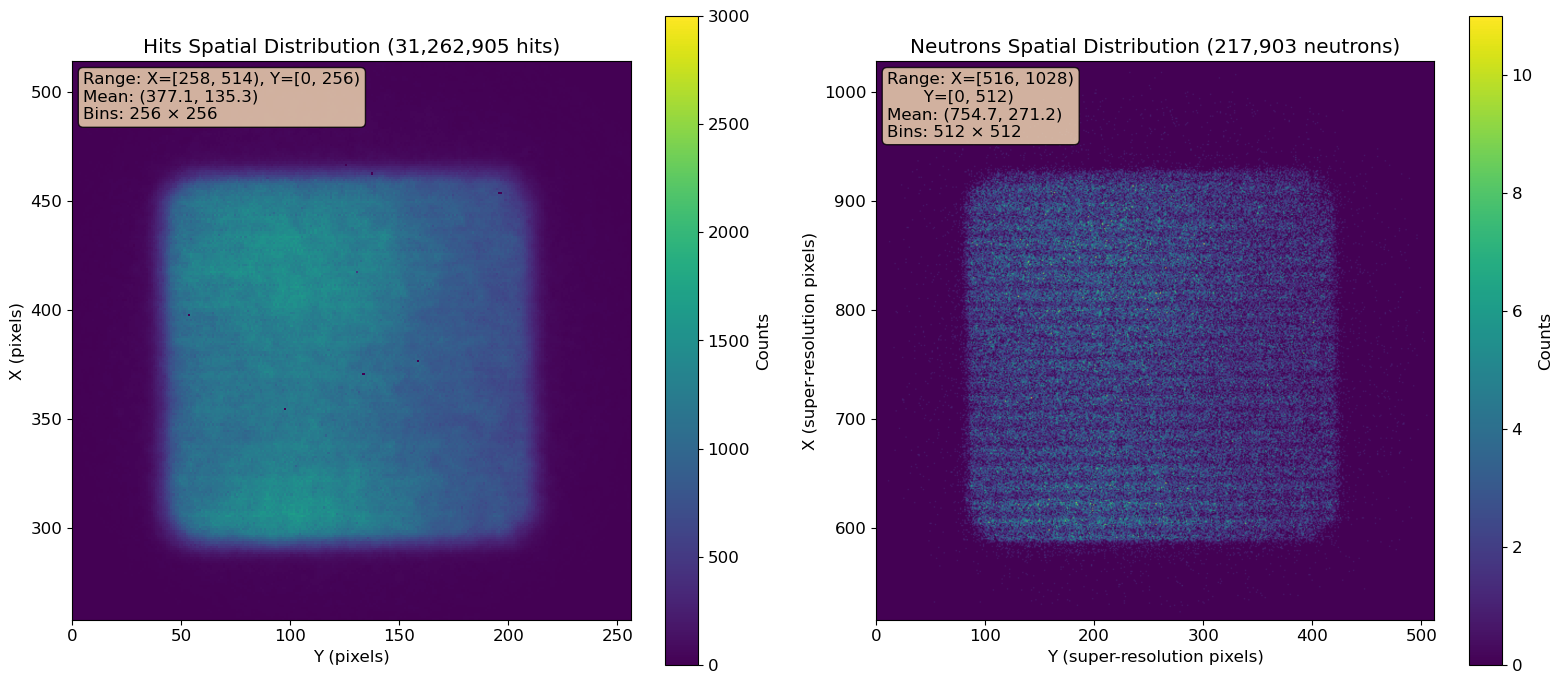


=== Spatial Distribution Analysis (Actual Data Region) ===
Region of interest: X=[258, 514), Y=[0, 256)
Super-resolution factor: 2.0x

Hits (native pixels):
  X range: 258 - 513
  Y range: 0 - 255
  Total hits in region: 31,262,905

Neutrons (super-resolution pixels):
  X range: 527.1 - 1020.5
  Y range: 10.2 - 504.5
  Total neutrons in region: 217,903
  Data reduction: 143.5:1


In [10]:
print("=== Creating spatial distribution visualizations (Filtered to Data Region) ===")

# VENUS detector has 514x514 pixels (256*2 + 2 pixel gap)
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2

# use super-resolution factor from config
NEUTRON_SUPER_RES = config.extraction.super_resolution_factor

# Define region of interest based on actual data range
# Data is in x: 258-513, y: 0-255 (top-right quadrant)
X_MIN, X_MAX = 258, 514
Y_MIN, Y_MAX = 0, 256

# Filter hits to region of interest
hits_mask = (hits["x"] >= X_MIN) & (hits["x"] < X_MAX) & (hits["y"] >= Y_MIN) & (hits["y"] < Y_MAX)
hits_filtered = hits[hits_mask]

# Filter neutrons to region of interest (in super-resolution coordinates)
neutrons_x_min = X_MIN * NEUTRON_SUPER_RES
neutrons_x_max = X_MAX * NEUTRON_SUPER_RES
neutrons_y_min = Y_MIN * NEUTRON_SUPER_RES
neutrons_y_max = Y_MAX * NEUTRON_SUPER_RES

neutrons_mask = (neutrons["x"] >= neutrons_x_min) & (neutrons["x"] < neutrons_x_max) & \
                (neutrons["y"] >= neutrons_y_min) & (neutrons["y"] < neutrons_y_max)
neutrons_filtered = neutrons[neutrons_mask]

print(f"Filtered to region: X=[{X_MIN}, {X_MAX}), Y=[{Y_MIN}, {Y_MAX})")
print(f"  Hits in region: {len(hits_filtered):,} / {len(hits):,} ({100*len(hits_filtered)/len(hits):.1f}%)")
print(f"  Neutrons in region: {len(neutrons_filtered):,} / {len(neutrons):,} ({100*len(neutrons_filtered)/len(neutrons):.1f}%)")

# Create figure with two subplots for better comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Hits distribution (native pixels)
print("\nCreating hits 2D histogram...")
# Use all filtered hits (no sampling needed - only 12M hits)
hits_x_sample = hits_filtered["x"]
hits_y_sample = hits_filtered["y"]

# Use bins matching the region size
X_BINS = X_MAX - X_MIN
Y_BINS = Y_MAX - Y_MIN

hist_hits, x_edges, y_edges = np.histogram2d(
    hits_x_sample,
    hits_y_sample,
    bins=[X_BINS, Y_BINS],
    range=[[X_MIN, X_MAX], [Y_MIN, Y_MAX]],
)

# Rotate 90 degrees counterclockwise
hist_hits_rotated = np.rot90(hist_hits)

im1 = ax1.imshow(
    hist_hits_rotated,
    origin="lower",
    aspect="equal",
    extent=[Y_MIN, Y_MAX, X_MIN, X_MAX],  # Swap X and Y extents
    cmap="viridis",
    interpolation="none",
    vmax=3000
)
ax1.set_xlabel("Y (pixels)")  # Swap labels
ax1.set_ylabel("X (pixels)")
ax1.set_title(f"Hits Spatial Distribution ({len(hits_filtered):,} hits)")
plt.colorbar(im1, ax=ax1, label="Counts")

# Add statistics
stats_text = f"Range: X=[{X_MIN}, {X_MAX}), Y=[{Y_MIN}, {Y_MAX})\n"
stats_text += f"Mean: ({hits_x_sample.mean():.1f}, {hits_y_sample.mean():.1f})\n"
stats_text += f"Bins: {X_BINS} × {Y_BINS}"
ax1.text(
    0.02,
    0.98,
    stats_text,
    transform=ax1.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Neutrons distribution (super-resolution pixels)
print("Creating neutrons 2D histogram...")
neutrons_x_filtered = neutrons_filtered["x"]
neutrons_y_filtered = neutrons_filtered["y"]

# Use super-resolution bins
NEUTRON_X_BINS = int(X_BINS * NEUTRON_SUPER_RES)
NEUTRON_Y_BINS = int(Y_BINS * NEUTRON_SUPER_RES)

hist_neutrons, x_edges_n, y_edges_n = np.histogram2d(
    neutrons_x_filtered,
    neutrons_y_filtered,
    bins=[NEUTRON_X_BINS, NEUTRON_Y_BINS],
    range=[[neutrons_x_min, neutrons_x_max], [neutrons_y_min, neutrons_y_max]],
)

# Rotate 90 degrees counterclockwise
hist_neutrons_rotated = np.rot90(hist_neutrons)

im2 = ax2.imshow(
    hist_neutrons_rotated,
    origin="lower",
    aspect="equal",
    extent=[neutrons_y_min, neutrons_y_max, neutrons_x_min, neutrons_x_max],  # Swap X and Y extents
    cmap="viridis",
    interpolation="gaussian",
)
ax2.set_xlabel("Y (super-resolution pixels)")  # Swap labels
ax2.set_ylabel("X (super-resolution pixels)")
ax2.set_title(f"Neutrons Spatial Distribution ({len(neutrons_filtered):,} neutrons)")
plt.colorbar(im2, ax=ax2, label="Counts")

# Add statistics
stats_text = f"Range: X=[{neutrons_x_min:.0f}, {neutrons_x_max:.0f})\n"
stats_text += f"       Y=[{neutrons_y_min:.0f}, {neutrons_y_max:.0f})\n"
stats_text += f"Mean: ({neutrons_x_filtered.mean():.1f}, {neutrons_y_filtered.mean():.1f})\n"
stats_text += f"Bins: {NEUTRON_X_BINS} × {NEUTRON_Y_BINS}"
ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n=== Spatial Distribution Analysis (Actual Data Region) ===")
print(f"Region of interest: X=[{X_MIN}, {X_MAX}), Y=[{Y_MIN}, {Y_MAX})")
print(f"Super-resolution factor: {NEUTRON_SUPER_RES}x")

print("\nHits (native pixels):")
print(f"  X range: {hits_filtered['x'].min()} - {hits_filtered['x'].max()}")
print(f"  Y range: {hits_filtered['y'].min()} - {hits_filtered['y'].max()}")
print(f"  Total hits in region: {len(hits_filtered):,}")

print("\nNeutrons (super-resolution pixels):")
print(f"  X range: {neutrons_x_filtered.min():.1f} - {neutrons_x_filtered.max():.1f}")
print(f"  Y range: {neutrons_y_filtered.min():.1f} - {neutrons_y_filtered.max():.1f}")
print(f"  Total neutrons in region: {len(neutrons_filtered):,}")
if len(neutrons_filtered) > 0:
    print(f"  Data reduction: {len(hits_filtered) / len(neutrons_filtered):.1f}:1")

=== Creating Neutron Spatial Distribution (Filtered to Data Region) ===
Filtered to region: X=[258, 514), Y=[0, 256)
  Neutrons in region: 217,903 / 217,903 (100.0%)

Creating neutrons 2D histogram...


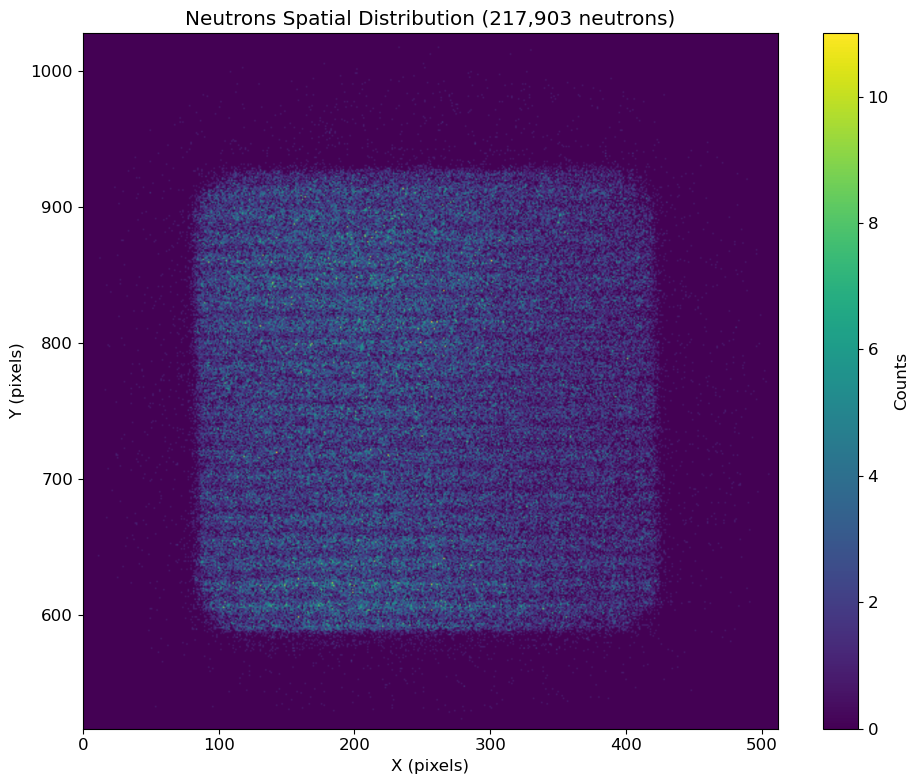


=== Neutron Spatial Distribution Analysis ===
Region of interest: X=[258, 514), Y=[0, 256)
Super-resolution factor: 2.0x
  X range: 527.1 - 1020.5 (super-res)
  Y range: 10.2 - 504.5 (super-res)
  Total neutrons in region: 217,903
  Bins: 512 × 512


: 

In [ ]:
print("=== Creating Neutron Spatial Distribution (Filtered to Data Region) ===")

# VENUS detector has 514x514 pixels (256*2 + 2 pixel gap)
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2

# use super-resolution factor from config
NEUTRON_SUPER_RES = config.extraction.super_resolution_factor

# Define region of interest based on actual data range
# Data is in x: 258-513, y: 0-255 (top-right quadrant)
X_MIN, X_MAX = 258, 514
Y_MIN, Y_MAX = 0, 256

# Filter neutrons to region of interest (in super-resolution coordinates)
neutrons_x_min = X_MIN * NEUTRON_SUPER_RES
neutrons_x_max = X_MAX * NEUTRON_SUPER_RES
neutrons_y_min = Y_MIN * NEUTRON_SUPER_RES
neutrons_y_max = Y_MAX * NEUTRON_SUPER_RES

neutrons_mask = (neutrons["x"] >= neutrons_x_min) & (neutrons["x"] < neutrons_x_max) & \
                (neutrons["y"] >= neutrons_y_min) & (neutrons["y"] < neutrons_y_max)
neutrons_filtered = neutrons[neutrons_mask]

print(f"Filtered to region: X=[{X_MIN}, {X_MAX}), Y=[{Y_MIN}, {Y_MAX})")
print(f"  Neutrons in region: {len(neutrons_filtered):,} / {len(neutrons):,} ({100*len(neutrons_filtered)/len(neutrons):.1f}%)")

# Create single figure for neutrons
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Neutrons distribution
print("\nCreating neutrons 2D histogram...")
neutrons_x_filtered = neutrons_filtered["x"]
neutrons_y_filtered = neutrons_filtered["y"]

# Use super-resolution bins
X_BINS = X_MAX - X_MIN
Y_BINS = Y_MAX - Y_MIN
NEUTRON_X_BINS = int(X_BINS * NEUTRON_SUPER_RES)
NEUTRON_Y_BINS = int(Y_BINS * NEUTRON_SUPER_RES)

hist_neutrons, x_edges_n, y_edges_n = np.histogram2d(
    neutrons_x_filtered,
    neutrons_y_filtered,
    bins=[NEUTRON_X_BINS, NEUTRON_Y_BINS],
    range=[[neutrons_x_min, neutrons_x_max], [neutrons_y_min, neutrons_y_max]],
)

# Rotate 90 degrees counterclockwise
hist_neutrons_rotated = np.rot90(hist_neutrons)
np.savetxt(
    'neutron_spatial_histogram.csv',
    hist_neutrons_rotated,
    delimiter=',',
    fmt='%d',
    header=f'Neutron spatial distribution histogram ({NEUTRON_X_BINS}x{NEUTRON_Y_BINS} bins)',
    comments=''
)

im = ax.imshow(
    hist_neutrons_rotated,
    origin="lower",
    aspect="equal",
    extent=[neutrons_y_min, neutrons_y_max, neutrons_x_min, neutrons_x_max],
    cmap="viridis",
    interpolation="gaussian",
)

# # Convert axis labels from super-resolution to pixel coordinates
# y_ticks = ax.get_xticks()
# y_tick_labels = [f'{int(y / NEUTRON_SUPER_RES)}' for y in y_ticks]
# ax.set_xticklabels(y_tick_labels)

# x_ticks = ax.get_yticks()
# x_tick_labels = [f'{int(x / NEUTRON_SUPER_RES)}' for x in x_ticks]
# ax.set_yticklabels(x_tick_labels)

ax.set_ylabel("Y (pixels)")
ax.set_xlabel("X (pixels)")
ax.set_title(f"Neutrons Spatial Distribution ({len(neutrons_filtered):,} neutrons)")
plt.colorbar(im, ax=ax, label="Counts")

plt.tight_layout()
plt.savefig('neutron_image.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n=== Neutron Spatial Distribution Analysis ===")
print(f"Region of interest: X=[{X_MIN}, {X_MAX}), Y=[{Y_MIN}, {Y_MAX})")
print(f"Super-resolution factor: {NEUTRON_SUPER_RES}x")
print(f"  X range: {neutrons_x_filtered.min():.1f} - {neutrons_x_filtered.max():.1f} (super-res)")
print(f"  Y range: {neutrons_y_filtered.min():.1f} - {neutrons_y_filtered.max():.1f} (super-res)")
print(f"  Total neutrons in region: {len(neutrons_filtered):,}")
print(f"  Bins: {NEUTRON_X_BINS} × {NEUTRON_Y_BINS}")

## 8. TOF Analysis

=== TOF Analysis ===
TOF ranges:
  Hits: 0.000 - 16.654 ms
  Neutrons: 0.000 - 16.652 ms


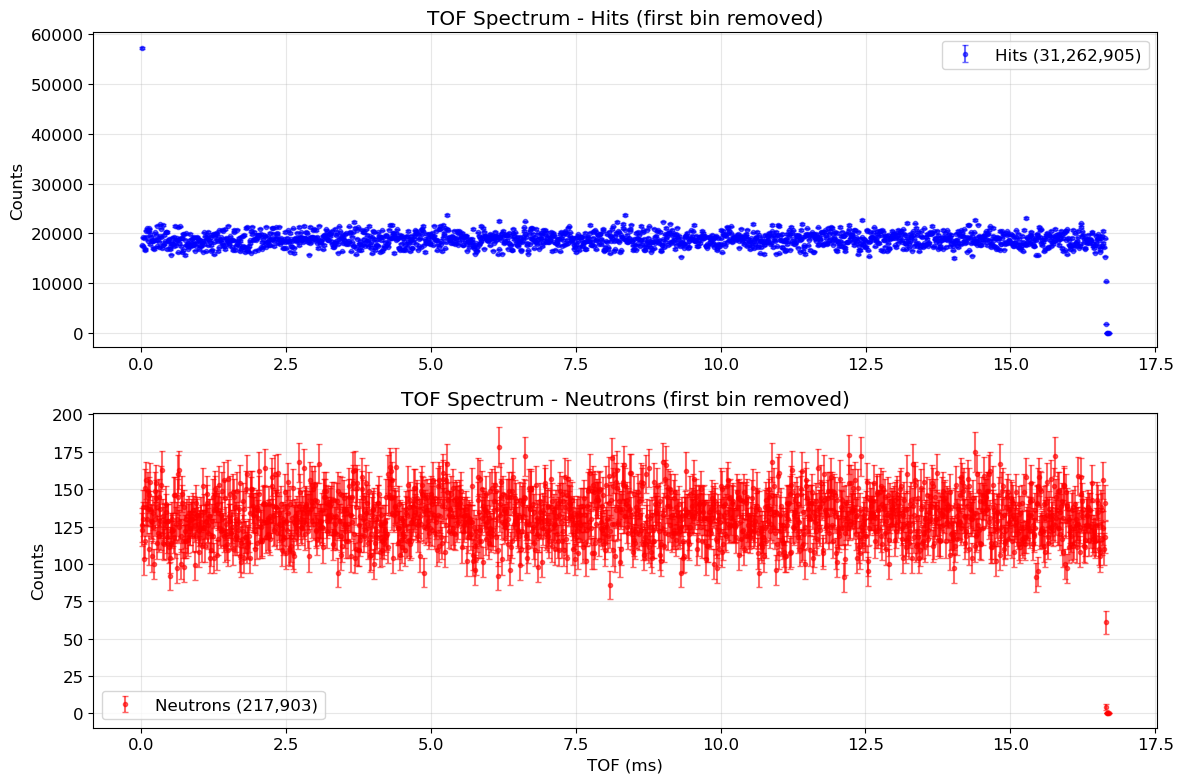

In [11]:
print("=== TOF Analysis ===")

# Convert TOF to milliseconds
hits_tof_ms = hits["tof"] * 25 / 1e6  # 25ns units to ms
neutrons_tof = neutrons["tof"]
neutrons_tof_ms = neutrons_tof * 25 / 1e6

print(f"TOF ranges:")
print(f"  Hits: {hits_tof_ms.min():.3f} - {hits_tof_ms.max():.3f} ms")
print(f"  Neutrons: {neutrons_tof_ms.min():.3f} - {neutrons_tof_ms.max():.3f} ms")

# Create TOF spectra using binning for scatter plot
tof_bins = np.linspace(0, 16.7, 1670)  # 0-16.7 ms in 1670 bins

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Hits TOF spectrum - bin the data first
hist_hits, edges_hits = np.histogram(hits_tof_ms, bins=tof_bins)
centers_hits = (edges_hits[:-1] + edges_hits[1:]) / 2
errors_hits = np.sqrt(hist_hits)  # Poisson error: sqrt(N)

# Remove first bin
# centers_hits = centers_hits[1:]
# hist_hits = hist_hits[1:]
# errors_hits = errors_hits[1:]

ax1.errorbar(
    centers_hits,
    hist_hits,
    yerr=errors_hits,
    fmt='o',
    markersize=3,
    capsize=2,
    alpha=0.6,
    color="blue",
    label=f"Hits ({len(hits_tof_ms):,})",
)
ax1.set_ylabel("Counts")
ax1.set_title("TOF Spectrum - Hits (first bin removed)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Neutrons TOF spectrum - bin the data first
hist_neutrons, edges_neutrons = np.histogram(neutrons_tof_ms, bins=tof_bins)
centers_neutrons = (edges_neutrons[:-1] + edges_neutrons[1:]) / 2
errors_neutrons = np.sqrt(hist_neutrons)  # Poisson error: sqrt(N)

# Remove first bin
centers_neutrons = centers_neutrons[1:]
hist_neutrons = hist_neutrons[1:]
errors_neutrons = errors_neutrons[1:]

ax2.errorbar(
    centers_neutrons,
    hist_neutrons,
    yerr=errors_neutrons,
    fmt='o',
    markersize=3,
    capsize=2,
    alpha=0.6,
    color="red",
    label=f"Neutrons ({len(neutrons_tof_ms):,})",
)
ax2.set_xlabel("TOF (ms)")
ax2.set_ylabel("Counts")
ax2.set_title("TOF Spectrum - Neutrons (first bin removed)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.errorbar(
    centers_neutrons,
    hist_neutrons,
    yerr=errors_neutrons,
    fmt='o',
    markersize=3,
    capsize=2,
    alpha=0.6,
    color="red",
    label=f"Neutrons ({len(neutrons_tof_ms):,})",
)
ax.set_xlabel("TOF (ms)")
ax.set_ylabel("Counts")
ax.set_title("TOF Spectrum - Neutrons (first bin removed)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('neutron_tof_spectrum.png', dpi=300, bbox_inches='tight')
plt.close()

# Save data to TXT file
data_array = np.column_stack((centers_neutrons, hist_neutrons))
np.savetxt(
    'neutron_tof_data.txt',
    data_array,
    header='TOF(ms)\tCounts',
    fmt=['%.6f', '%d'],
    delimiter='\t',
    comments=''
)

print("✅ Files saved successfully:")
print("   - neutron_tof_spectrum.png (TOF spectrum plot)")
print("   - neutron_tof_data.txt (TOF vs Counts data)")

✅ Files saved successfully:
   - neutron_tof_spectrum.png (TOF spectrum plot)
   - neutron_tof_data.txt (TOF vs Counts data)


## 9. Summary and Verification

In [13]:
print("=== Clustering Verification Summary ===")
print()
print("✅ TPX3 file processing: SUCCESS")
print(f"   - Processed {len(hits):,} hits in {processing_time:.2f} seconds")
print(f"   - Rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")
print()
print("✅ Clustering pipeline: SUCCESS")
print(f"   - Input: {len(hits):,} hits")
print(f"   - Output: {len(neutrons):,} neutrons")
print(f"   - Efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")
print(f"   - Processing time: {clustering_time:.2f} seconds")
print()
print("✅ Sub-pixel precision: CONFIRMED")
print(f"   - {non_integer_x:,} neutrons have non-integer X coordinates")
print(f"   - {non_integer_y:,} neutrons have non-integer Y coordinates")
print()
print("✅ Cluster analysis: COMPLETE")
print(f"   - Mean cluster size: {n_hits_field.mean():.1f} hits")
print(f"   - Cluster size range: {n_hits_field.min()} - {n_hits_field.max()} hits")
print(
    f"   - Multi-hit clusters: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)"
)

=== Clustering Verification Summary ===

✅ TPX3 file processing: SUCCESS
   - Processed 31,262,905 hits in 0.00 seconds
   - Rate: 158173.9 M hits/second

✅ Clustering pipeline: SUCCESS
   - Input: 31,262,905 hits
   - Output: 217,903 neutrons
   - Efficiency: 0.006970 (0.6970%)
   - Processing time: 0.37 seconds

✅ Sub-pixel precision: CONFIRMED
   - 217,416 neutrons have non-integer X coordinates
   - 217,419 neutrons have non-integer Y coordinates

✅ Cluster analysis: COMPLETE
   - Mean cluster size: 67.3 hits
   - Cluster size range: 25 - 344 hits
   - Multi-hit clusters: 217,903 (100.0%)
